# Demonstrating ReLU and Leaky ReLU

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
import seaborn as sns
import warnings

In [2]:
sns.set_style("darkgrid")
warnings.filterwarnings(action="ignore")

## 2. Activation plot

In [3]:
def relu(x):
    """
    ReLU: f(x) = max(0, x)
    Range: [0, +inf)
    Kills all negative values → can cause dying neurons
    """
    return np.maximum(0, x)

In [4]:
def leaky_relu(x, alpha=0.01):
    """
    Leaky ReLU: f(x) = x if x >= 0 else alpha * x
    Range: (-inf, +inf)
    Allows a small gradient for negatives → fixes dying neurons
    """
    return np.where(x >= 0, x, alpha * x)

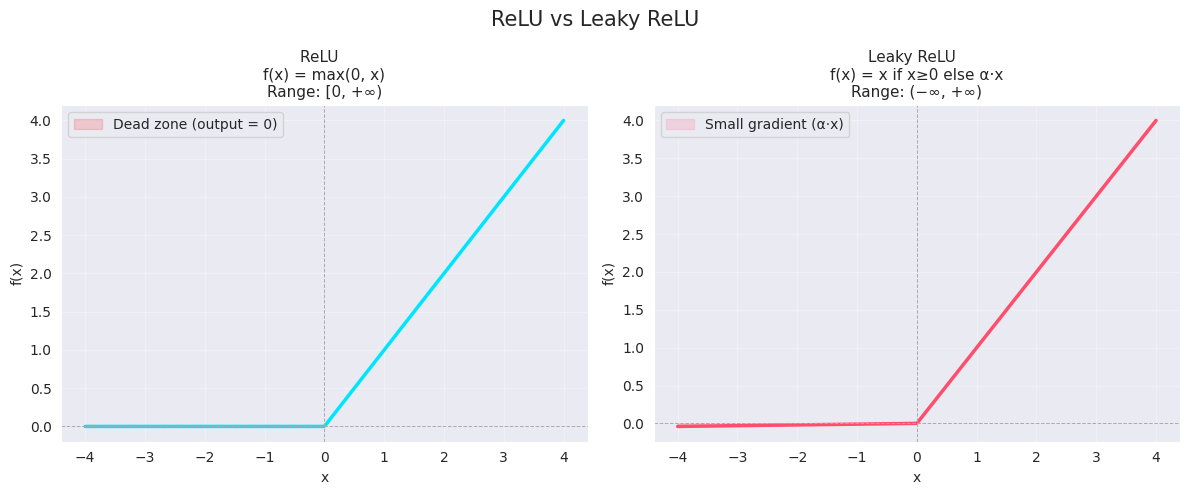

In [5]:
x = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ReLU vs Leaky ReLU", fontsize=15)

# ReLU
axes[0].plot(x, relu(x), color="#00e5ff", linewidth=2.5)
axes[0].axhline(0, color="#aaaaaa", linewidth=0.7, linestyle="--")
axes[0].axvline(0, color="#aaaaaa", linewidth=0.7, linestyle="--")
axes[0].fill_between(x, relu(x), where=(x < 0), color="red", alpha=0.15, label="Dead zone (output = 0)")
axes[0].set_title("ReLU  \nf(x) = max(0, x)\nRange: [0, +∞)", fontsize=11)
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Leaky ReLU
axes[1].plot(x, leaky_relu(x, alpha=0.01), color="#ff4d6d", linewidth=2.5)
axes[1].axhline(0, color="#aaaaaa", linewidth=0.7, linestyle="--")
axes[1].axvline(0, color="#aaaaaa", linewidth=0.7, linestyle="--")
axes[1].fill_between(x, leaky_relu(x, 0.01), where=(x < 0), color="#ff4d6d", alpha=0.15, label="Small gradient (α·x)")
axes[1].set_title("Leaky ReLU  \nf(x) = x if x≥0 else α·x\nRange: (−∞, +∞)", fontsize=11)
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Interactive Alpha

In [6]:
x = np.linspace(-4, 4, 400)

In [7]:
alphas = np.concatenate([
    np.full(10, 0.01),           # hold at start
    np.linspace(0.01, 0.5, 45),  # ramp up
    np.full(10, 0.5),            # hold at peak
    np.linspace(0.5, 0.01, 45),  # ramp down
])

plt.rcParams.update({
    "axes.facecolor": "#ffffff", "figure.facecolor": "#ffffff",
    "axes.edgecolor": "#cccccc", "axes.labelcolor": "#333333",
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#eeeeee", "text.color": "#333333",
})

In [8]:
def update(i):
    alpha = alphas[i]
    leaky_line.set_ydata(leaky_relu(x, alpha))
    fill[0].remove()
    fill[0] = ax.fill_between(x[x < 0], relu(x[x < 0]), leaky_relu(x[x < 0], alpha),
                               alpha=0.12, color="#e63946")
    legend.get_texts()[1].set_text(f"LeakyReLU  (α = {alpha:.3f})")
    alpha_text.set_text(f"α = {alpha:.3f}")
    return leaky_line, alpha_text

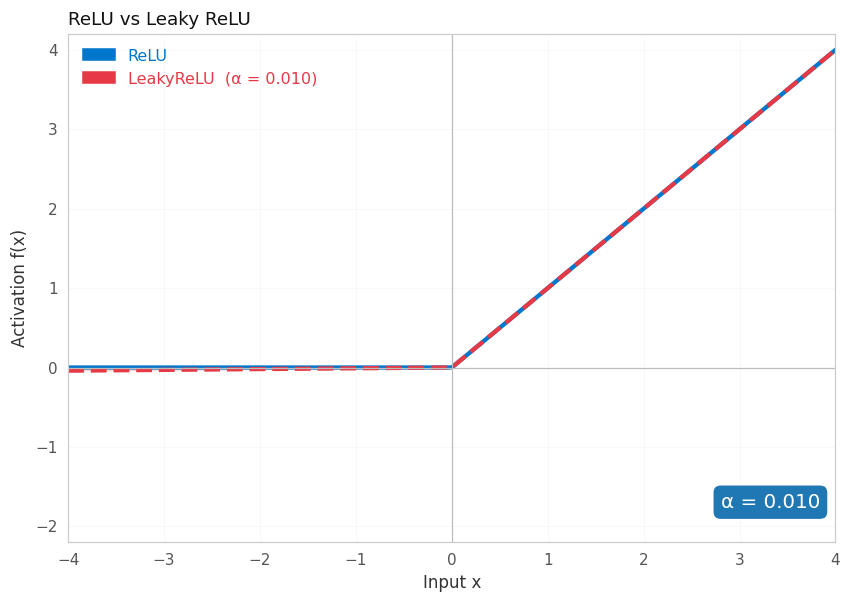

In [9]:
fig, ax = plt.subplots(figsize=(9, 6), dpi=110)
relu_line, = ax.plot(x, relu(x), color="#0077cc", linewidth=2.8, label="ReLU")
leaky_line, = ax.plot(x, leaky_relu(x, 0.01), color="#e63946", linewidth=2.8, linestyle="--")

fill = [ax.fill_between(x[x < 0], relu(x[x < 0]), leaky_relu(x[x < 0], 0.01),
                         alpha=0.12, color="#e63946")]

ax.axhline(0, color="#bbbbbb", linewidth=0.8)
ax.axvline(0, color="#bbbbbb", linewidth=0.8)
ax.set_xlim(-4, 4); ax.set_ylim(-2.2, 4.2)
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.set_xlabel("Input x", fontsize=11)
ax.set_ylabel("Activation f(x)", fontsize=11)
ax.set_title("ReLU vs Leaky ReLU", fontsize=12, color="#111111", fontweight="normal", loc="left")

relu_patch = mpatches.Patch(color="#0077cc", label="ReLU")
leaky_patch = mpatches.Patch(color="#e63946", label="LeakyReLU  (α = 0.010)")
legend = ax.legend(handles=[relu_patch, leaky_patch], loc="upper left",
                   frameon=False, fontsize=10.5,
                   labelcolor=["#0077cc", "#e63946"])

alpha_text = ax.text(0.98, 0.06, "α = 0.010", transform=ax.transAxes,
                     ha="right", va="bottom", fontsize=13, color="white", fontweight="normal",
                     bbox=dict(boxstyle="round,pad=0.4"))

ani = FuncAnimation(fig, update, frames=len(alphas), interval=60, blit=False)
ani.save("relu_vs_leakyrelu.gif", writer=PillowWriter(fps=20), dpi=150)
plt.show()